<a href="https://colab.research.google.com/github/hrk022/story_generator/blob/main/story_generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.layers import Dense,LSTM,Embedding,Dropout, TimeDistributed, RepeatVector, Bidirectional # Changed Embdding to Embedding
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import to_categorical
from collections import Counter

In [ ]:
with open("mahabharat.txt",'r',encoding='utf-8')as file:
  text = file.read()

In [ ]:
def clean(text):
  start = text.find("THE MAHABHARATA")
  end = text.rfind("End of the Project Gutenberg")
  text = text[start:end].lower().replace("\n"," ").replace('\r','')
  clean = ' '.join(text.split())
  return clean

In [ ]:
text = clean(text)
text = ' '.join(text.split()[:50000])

In [ ]:

tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts([text])
vocab_size = len(tokenizer.word_index) + 1


In [ ]:
len(tokenizer.word_index)

5765

In [ ]:
sequence = tokenizer.texts_to_sequences([text])[0]

In [ ]:
input_seq_len = 20
output_seq_len = 10

  # or any window size like 30, 50 etc.

In [ ]:
X_encoder, X_decoder, Y = [], [], []

for i in range(input_seq_len, len(sequence) - output_seq_len):
    encoder_seq = sequence[i - input_seq_len:i]
    decoder_input_seq = sequence[i:i + output_seq_len]
    decoder_output_seq = sequence[i + 1:i + output_seq_len + 1]

    X_encoder.append(encoder_seq)
    X_decoder.append(decoder_input_seq)
    Y.append(decoder_output_seq)

X_encoder = np.array(X_encoder)
X_decoder = np.array(X_decoder)
Y = np.array(Y)
Y = np.expand_dims(Y, -1)  # needed for sparse_categorical_crossentropy

# Split
X_enc_train, X_enc_test, X_dec_train, X_dec_test, y_train, y_test = train_test_split(
    X_encoder, X_decoder, Y, test_size=0.1, random_state=42)

In [ ]:
count = text.split()
count = len(count)
count

50000

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, TimeDistributed

embedding_dim = 256
latent_dim = 256

# Encoder
encoder_input = Input(shape=(input_seq_len,))
encoder_embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim, mask_zero=True)(encoder_input)
_, state_h, state_c = LSTM(latent_dim, return_state=True)(encoder_embedding)
encoder_states = [state_h, state_c]

# Decoder
decoder_input = Input(shape=(output_seq_len,))
decoder_embedding = Embedding(input_dim=vocab_size, output_dim=embedding_dim)(decoder_input)
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True)
decoder_output, _, _ = decoder_lstm(decoder_embedding, initial_state=encoder_states)
decoder_dense = TimeDistributed(Dense(vocab_size, activation='softmax'))
decoder_output = decoder_dense(decoder_output)

# Model
model = Model([encoder_input, decoder_input], decoder_output)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_16      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_10        │ (None, 20, 256)   │  1,476,096 │ input_layer_15[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_14        │ (None, 20)        │          0 │ input_layer_15[0… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_11        │ (None, 10, 256)   │  1,476,096 │ input_layer_16[0… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ [(None, 256),     │    525,312 │ embedding_10[0][… │
│                     │ (None, 256),      │            │ not_equal_14[0][… │
│                     │ (None, 256)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_14 (LSTM)      │ [(None, 10, 256), │    525,312 │ embedding_11[0][… │
│                     │ (None, 256),      │            │ lstm_13[0][1],    │
│                     │ (None, 256)]      │            │ lstm_13[0][2]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 10, 5766)  │  1,481,862 │ lstm_14[0][0]     │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 5,484,678 (20.92 MB)

 Trainable params: 5,484,678 (20.92 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
es = EarlyStopping(monitor='val_accuracy',patience=3,mode='max',verbose=1)
lr = ReduceLROnPlateau(monitor='val_accuracy',patience=2,mode='max',verbose=1,factor=0.1,min_lr=0.001)

In [ ]:
dummy_decoder_input = np.zeros((X_train.shape[0], output_size), dtype=np.int64)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
lr = ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.1)

model.fit([X_enc_train, X_dec_train], y_train,
          validation_data=([X_enc_test, X_dec_test], y_test),
          batch_size=256, epochs=30, callbacks=[es, lr])


Epoch 1/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.0884 - loss: 6.9783 - val_accuracy: 0.1384 - val_loss: 5.9208 - learning_rate: 0.0010
Epoch 2/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.1483 - loss: 5.7420 - val_accuracy: 0.1844 - val_loss: 5.3748 - learning_rate: 0.0010
Epoch 3/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 44ms/step - accuracy: 0.1975 - loss: 5.2423 - val_accuracy: 0.2138 - val_loss: 4.9830 - learning_rate: 0.0010
Epoch 4/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - accuracy: 0.2235 - loss: 4.8576 - val_accuracy: 0.2371 - val_loss: 4.6515 - learning_rate: 0.0010
Epoch 5/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.2480 - loss: 4.5177 - val_accuracy: 0.2593 - val_loss: 4.3580 - learning_rate: 0.0010
Epoch 6/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.2697 - loss: 4.2236 - val_accuracy: 0.2807 - val_loss: 4.0941 - learning_rate: 0.0010
Epoch 7/30
179/179 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - accuracy: 0.2925 - loss

In [ ]:
# Save weights only (use .weights.h5 extension!)
model.save_weights("mahabharata.weights.h5")


In [ ]:
# Save model in native Keras format (recommended)
model.save("mahabharataa_model.keras")


In [ ]:
# Save model in native Keras format (recommended)
model.save("mahabharataa_model.keras")

model.load_weights("mahabharata_model.keras")


In [ ]:
model.save_weights("mahabharat_model.keras")


ValueError: The filename must end in `.weights.h5`. Received: filepath=mahabharat_model.keras

In [ ]:
# Load the model
from tensorflow.keras.models import load_model
model = load_model("mahabharata_model_tf")


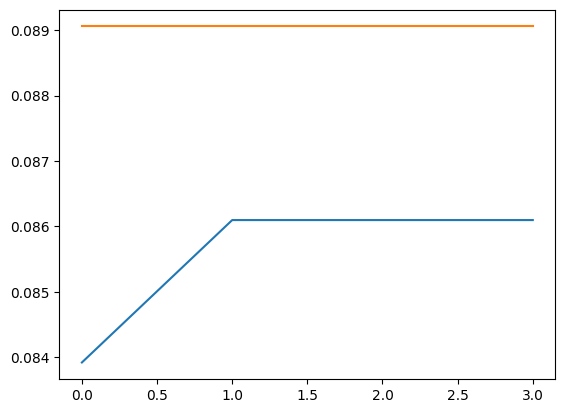

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.show()

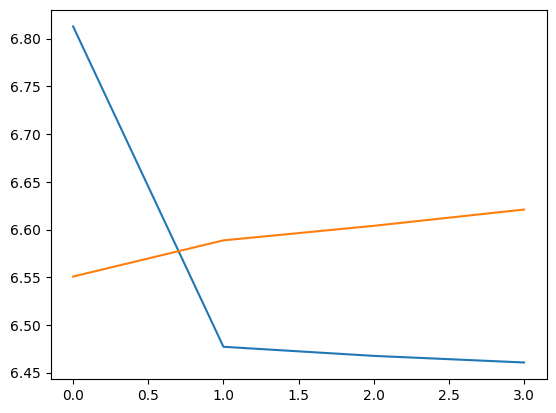

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.show()

In [ ]:
model.save("mahabharat_model.h5")

In [ ]:
model = load_model("mahabharat_model.h5")

ValueError: Only input tensors may be passed as positional arguments. The following argument value should be passed as a keyword argument: 0 (of type <class 'int'>)